# Homework 2 - Company Fundamental Deep Dive

## Step 0 - Company Selection

I selected Taiwan Semiconductor Manufacturing Company (TSM) because it is one of the largest companies in the Asian geographic group and a global leader in the semiconductor industry. The company shows strong profitability, a very large market capitalization, and a strategic role in the global technology supply chain. These characteristics make it an interesting company for analyzing profitability, valuation, growth, and financial strength relative to its peers. 

In [78]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [79]:
# ============================================================
# Step 1 - Dataset Loading
# ============================================================

df = pd.read_excel("Symbol_Info_extended.xlsx")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3070, 21)


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,1.290000e+09,7.065000e+09,0.08533,0.19946,...,25.377481,17.515205,-0.036,4.598437,4.704534,0.070,51.390,0.89,0.2205,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,1.027000e+09,1.265500e+10,0.04241,0.15427,...,18.302563,10.659156,-0.227,1.488460,2.759500,-0.052,37.019,0.56,0.1026,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,2.020000e+08,5.599400e+10,0.01846,NaN,...,44.677420,6.256155,NaN,0.163592,-2.246918,0.108,NaN,NaN,0.0000,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,8.420000e+07,6.108000e+08,0.12664,1.11725,...,30.459576,12.513987,0.264,4.175381,32.910347,0.393,346.579,0.56,0.0553,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-4.333700e+07,5.070000e+08,-0.03317,-0.06126,...,NaN,38.032272,NaN,28.724379,12.958943,0.514,25.356,NaN,0.0000,-4.455833e+08


In [80]:
# ============================================================
# Step 1 - Data Preparation
# ============================================================

cols = [
    'symbol',
    'company_name',
    'sector',
    'industry',
    'country',
    'market_cap',
    'return_on_assets',
    'return_on_equity',
    'profit_margins',
    'pe_trailing',
    'price_to_book',
    'revenue_growth',
    'debt_to_equity',
    'free_cashflow'
]

df = df[cols].copy()

# Replace infinite values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Remove invalid market capitalization
df = df[df['market_cap'] > 0]

# Clean valuation metrics
df.loc[df['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df.loc[df['price_to_book'] <= 0, 'price_to_book'] = np.nan

print(df.shape)

(2970, 14)


In [81]:
# ============================================================
# Step 2 - Company Selection
# ============================================================

company = df[df['symbol'] == 'TSM'].iloc[0]

company

symbol                                                            TSM
company_name        Taiwan Semiconductor Manufacturing Company Lim...
sector                                                     Technology
industry                                               Semiconductors
country                                                        Taiwan
market_cap                                            2098032410624.0
return_on_assets                                              0.17322
return_on_equity                                               0.3621
profit_margins                                                0.46505
pe_trailing                                                 34.722748
price_to_book                                                 89.5262
revenue_growth                                                  0.351
debt_to_equity                                                 18.447
free_cashflow                                          719158444032.0
Name: 2759, dtype: o

In [82]:
# ============================================================
# Step 2 - Geographic Group Definition
# ============================================================

# Student ID ends in 6 -> Group 4 (Asia)

asia_countries = [
    'China',
    'Taiwan',
    'Singapore',
    'South Korea',
    'Hong Kong'
]

In [83]:
# ============================================================
# Group A - Same Industry
# ============================================================

industry = company['industry']

groupA = (
    df[df['industry'] == industry]
    .sort_values('market_cap', ascending=False)
)

groupA = groupA.head(10)

if 'TSM' not in groupA['symbol'].values:
    groupA = pd.concat([
        groupA,
        df[df['symbol'] == 'TSM']
    ])

print("Group A size:", len(groupA))

groupA[['symbol','company_name','market_cap']]

Group A size: 10


,symbol,company_name,market_cap
1967,NVDA,NVIDIA Corporation,5.215508e+12
2759,TSM,Taiwan Semiconductor Manufacturing Company Lim...,2.098032e+12
277,AVGO,Broadcom Inc.,1.960816e+12
1850,MU,"Micron Technology, Inc.",8.469282e+11
146,AMD,"Advanced Micro Devices, Inc.",7.623221e+11
1430,INTC,Intel Corporation,6.023158e+11
218,ARM,Arm Holdings plc,3.261262e+11
2783,TXN,Texas Instruments Incorporated,2.814098e+11
2249,QCOM,QUALCOMM Incorporated,2.510206e+11
48,ADI,"Analog Devices, Inc.",1.934076e+11


In [84]:
# ============================================================
# Group B - Same Geographic Group
# ============================================================

groupB = (
    df[df['country'].isin(asia_countries)]
    .sort_values('market_cap', ascending=False)
)

groupB = groupB.head(10)

if 'TSM' not in groupB['symbol'].values:
    groupB = pd.concat([
        groupB,
        df[df['symbol'] == 'TSM']
    ])

print("Group B size:", len(groupB))

groupB[['symbol','company_name','country','market_cap']]

Group B size: 10


,symbol,company_name,country,market_cap
2759,TSM,Taiwan Semiconductor Manufacturing Company Lim...,Taiwan,2.098032e+12
2609,STX,Seagate Technology Holdings plc,Singapore,1.822376e+11
245,ASX,"ASE Technology Holding Co., Ltd.",Taiwan,7.637126e+10
2434,SE,Sea Limited,Singapore,5.345153e+10
2819,UMC,United Microelectronics Corporation,Taiwan,4.571920e+10
1511,KB,KB Financial Group Inc.,South Korea,3.719965e+10
576,CHT,"Chunghwa Telecom Co., Ltd.",Taiwan,3.388453e+10
2162,PKX,POSCO Holdings Inc.,South Korea,2.254104e+10
3062,ZTO,ZTO Express (Cayman) Inc.,China,1.762494e+10
347,BEKE,KE Holdings Inc.,China,1.755779e+10


In [85]:
# ============================================================
# Group C - Closest Market Capitalization
# ============================================================

market_cap = company['market_cap']

groupC = df.copy()

groupC['distance'] = abs(
    groupC['market_cap'] - market_cap
)

groupC = groupC.sort_values('distance')

groupC = groupC.head(10)

print("Group C size:", len(groupC))

groupC[['symbol','company_name','market_cap']]

Group C size: 10


,symbol,company_name,market_cap
2759,TSM,Taiwan Semiconductor Manufacturing Company Lim...,2.098032e+12
277,AVGO,Broadcom Inc.,1.960816e+12
2758,TSLA,"Tesla, Inc.",1.599976e+12
1749,META,"Meta Platforms, Inc.",1.549098e+12
168,AMZN,"Amazon.com, Inc.",2.864834e+12
1828,MSFT,Microsoft Corporation,3.109320e+12
432,BRK-B,Berkshire Hathaway Inc.,1.049051e+12
431,BRK-A,Berkshire Hathaway Inc.,1.047715e+12
2983,WMT,Walmart Inc.,9.586710e+11
1634,LLY,Eli Lilly and Company,9.497046e+11


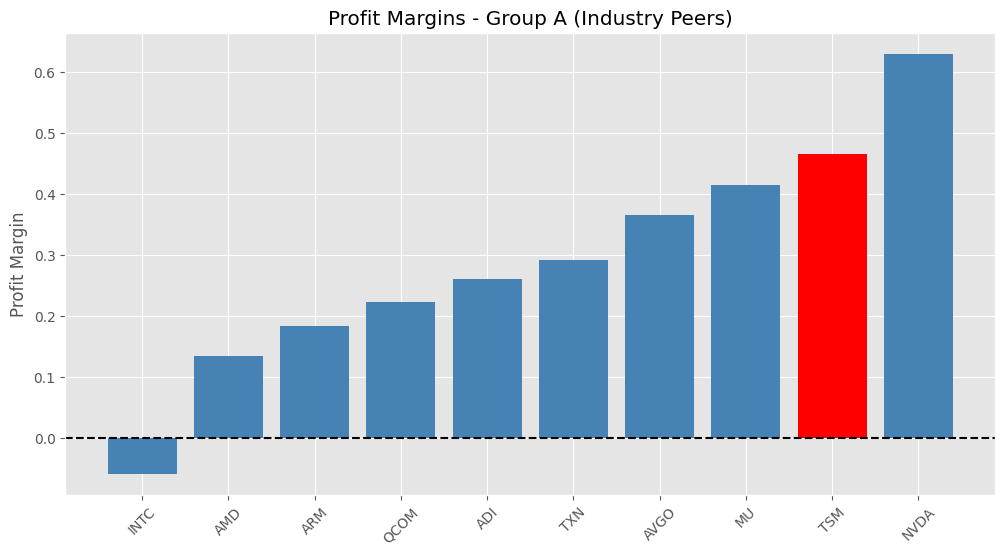

In [86]:
# ============================================================
# Step 3 - Business Question 1
# Is the Company Profitable?
# Metric 1: Profit Margins
# Group A - Same Industry
# ============================================================

# Keep only companies with a valid profit margin

pm_A = groupA.dropna(subset=['profit_margins']).copy()

# Sort companies from lowest to highest profitability

pm_A = pm_A.sort_values('profit_margins')

# Highlight the selected company (TSM)

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in pm_A['symbol']
]

# Create chart

plt.figure(figsize=(12,6))

plt.bar(
    pm_A['symbol'],
    pm_A['profit_margins'],
    color=colors
)

plt.title('Profit Margins - Group A (Industry Peers)')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)

plt.axhline(0, color='black', linestyle='--')

plt.show()


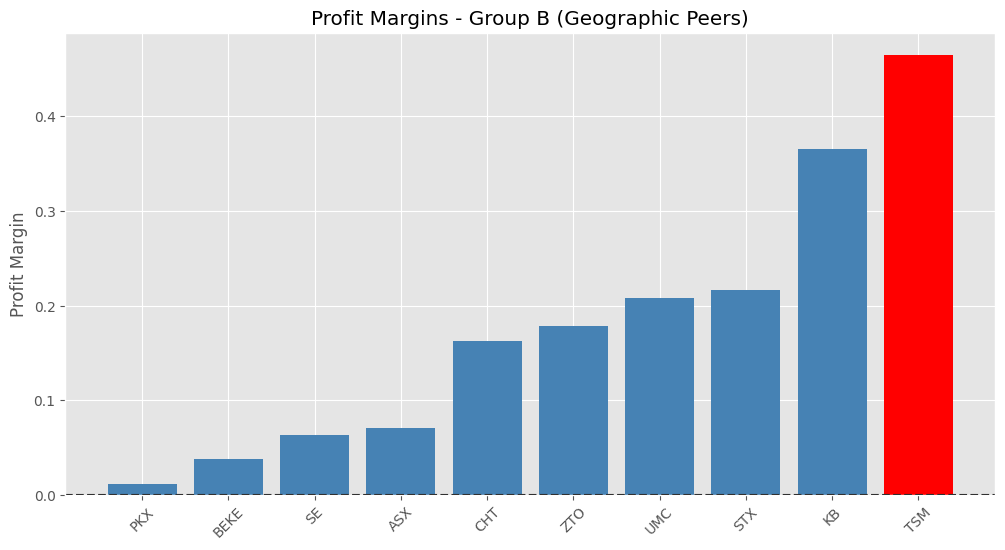

In [87]:
# ============================================================
# Step 3 - Business Question 1
# Is the Company Profitable?
# Metric 1: Profit Margins
# Group B - Geographic Peers
# ============================================================

pm_B = groupB.dropna(subset=['profit_margins']).copy()

pm_B = pm_B.sort_values('profit_margins')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in pm_B['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    pm_B['symbol'],
    pm_B['profit_margins'],
    color=colors
)

plt.title('Profit Margins - Group B (Geographic Peers)')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)

plt.axhline(0, color='black', linestyle='--')

plt.show()

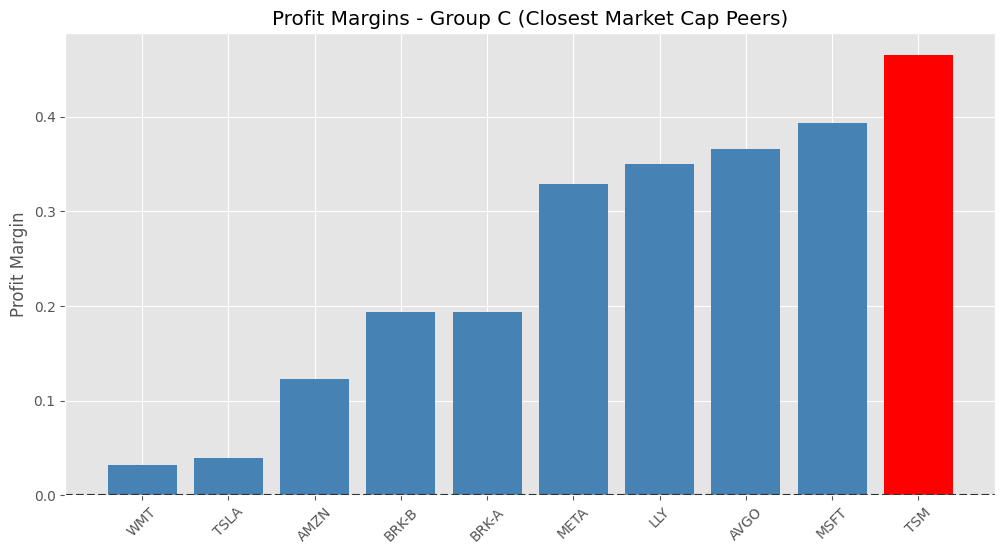

In [88]:
# ============================================================
# Step 3 - Business Question 1
# Is the Company Profitable?
# Metric 1: Profit Margins
# Group C - Closest Market Capitalization
# ============================================================

pm_C = groupC.dropna(subset=['profit_margins']).copy()

pm_C = pm_C.sort_values('profit_margins')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in pm_C['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    pm_C['symbol'],
    pm_C['profit_margins'],
    color=colors
)

plt.title('Profit Margins - Group C (Closest Market Cap Peers)')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)

plt.axhline(0, color='black', linestyle='--')

plt.show()

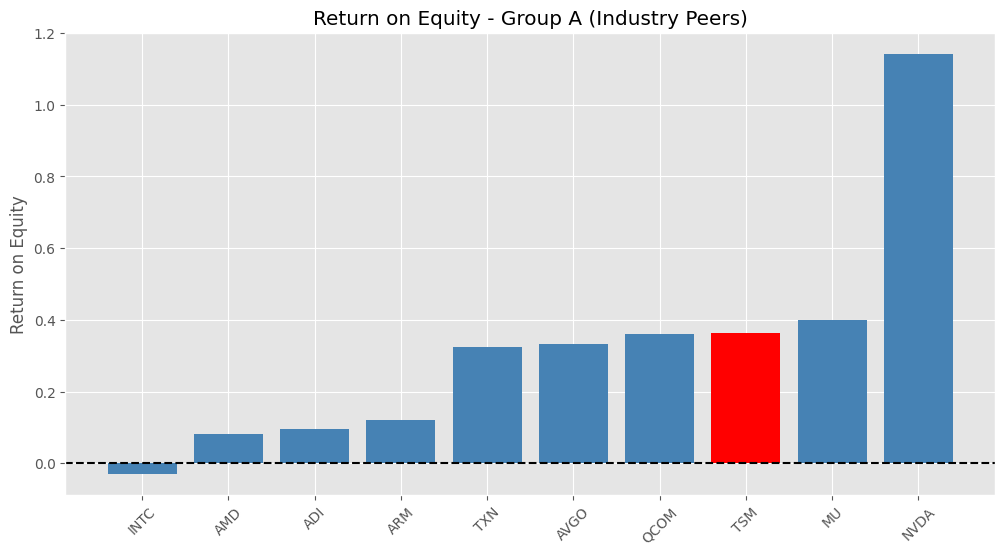

In [89]:
# ============================================================
# Step 3 - Business Question 1
# Is the Company Profitable?
# Metric 2: Return on Equity
# Group A - Industry Peers
# ============================================================

roe_A = groupA.dropna(subset=['return_on_equity']).copy()

roe_A = roe_A.sort_values('return_on_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in roe_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    roe_A['symbol'],
    roe_A['return_on_equity'],
    color=colors
)

# The homework explicitly notes that ROE can be negative.
plt.axhline(0, color='black', linestyle='--')

plt.title('Return on Equity - Group A (Industry Peers)')
plt.ylabel('Return on Equity')
plt.xticks(rotation=45)

plt.show()

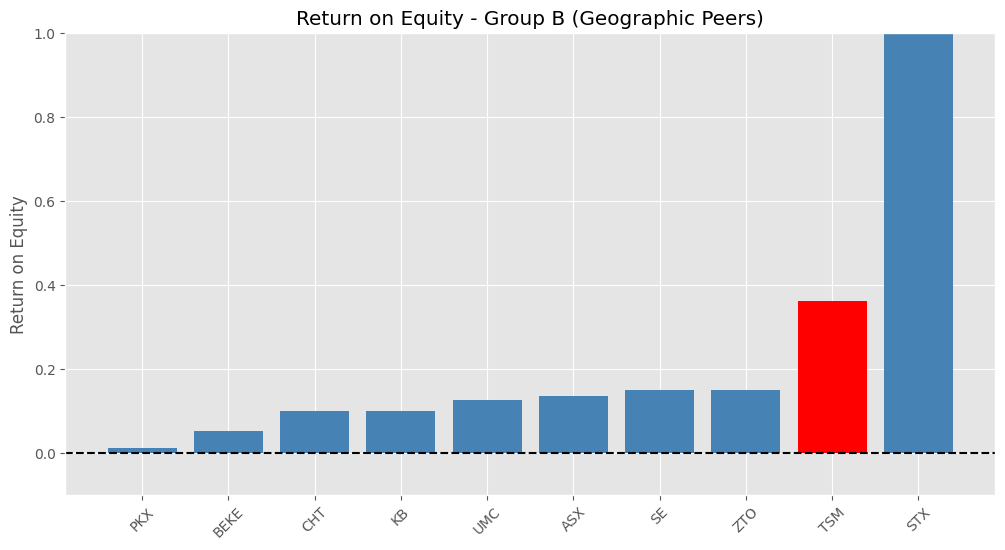

In [90]:
# ============================================================
# Step 3 - Business Question 1
# Return on Equity - Group B
# Outlier-adjusted visualization
# ============================================================

roe_B = groupB.dropna(subset=['return_on_equity']).copy()
roe_B = roe_B.sort_values('return_on_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in roe_B['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    roe_B['symbol'],
    roe_B['return_on_equity'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

# Cap the axis because STX is an extreme outlier
plt.ylim(-0.1, 1.0)

plt.title('Return on Equity - Group B (Geographic Peers)')
plt.ylabel('Return on Equity')
plt.xticks(rotation=45)

plt.show()

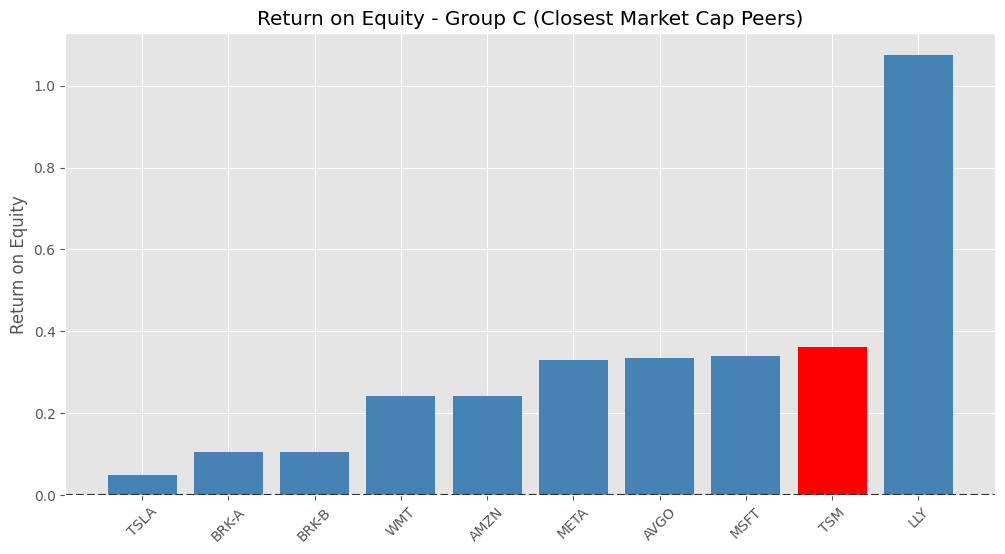

In [91]:
# ============================================================
# Step 3 - Business Question 1
# Is the Company Profitable?
# Metric 2: Return on Equity
# Group C - Closest Market Capitalization
# ============================================================

roe_C = groupC.dropna(subset=['return_on_equity']).copy()

roe_C = roe_C.sort_values('return_on_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in roe_C['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    roe_C['symbol'],
    roe_C['return_on_equity'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Return on Equity - Group C (Closest Market Cap Peers)')
plt.ylabel('Return on Equity')
plt.xticks(rotation=45)

plt.show()

### Business Question 1 - Interpretation

TSM shows very strong profitability across all peer groups.

For profit margins, TSM ranks among the top companies in the semiconductor industry, is the most profitable company in the geographic peer group, and is also the most profitable company among firms with similar market capitalization.

Return on Equity confirms this result. TSM is well above the median in all three peer groups and ranks among the strongest performers. Only a few companies, such as NVIDIA and Eli Lilly, achieve higher ROE values.

Overall, profit margins and ROE provide consistent evidence that TSM is a highly profitable company relative to both industry peers and companies of similar size.

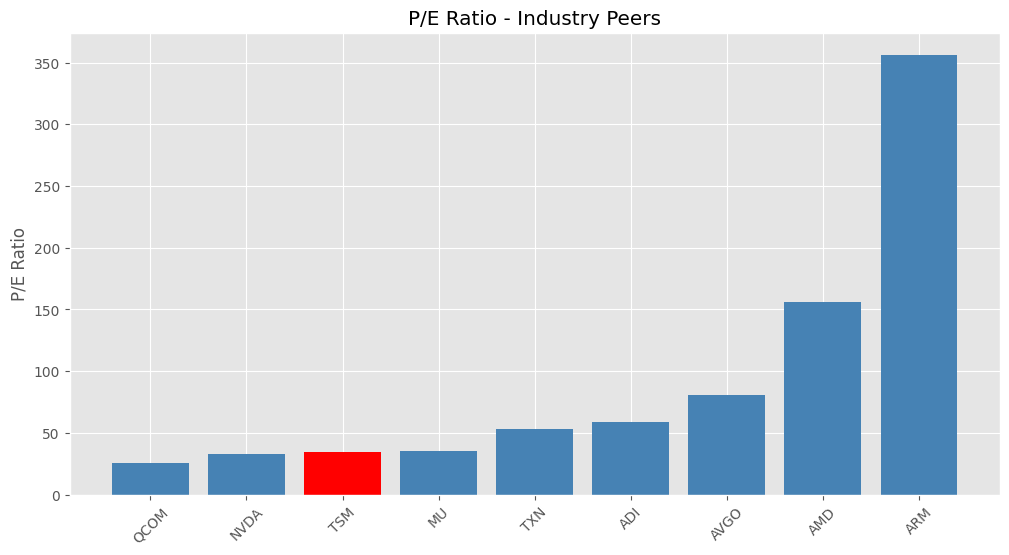

In [92]:
# ============================================================
# Step 4 - Business Question 2
# Is the Company Expensive or Cheap?
# Metric 1: Price-to-Earnings (P/E)
# Industry Peers Only (Group A)
# ============================================================

pe_A = groupA.dropna(subset=['pe_trailing']).copy()

pe_A = pe_A.sort_values('pe_trailing')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in pe_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    pe_A['symbol'],
    pe_A['pe_trailing'],
    color=colors
)

plt.title('P/E Ratio - Industry Peers')
plt.ylabel('P/E Ratio')
plt.xticks(rotation=45)

plt.show()

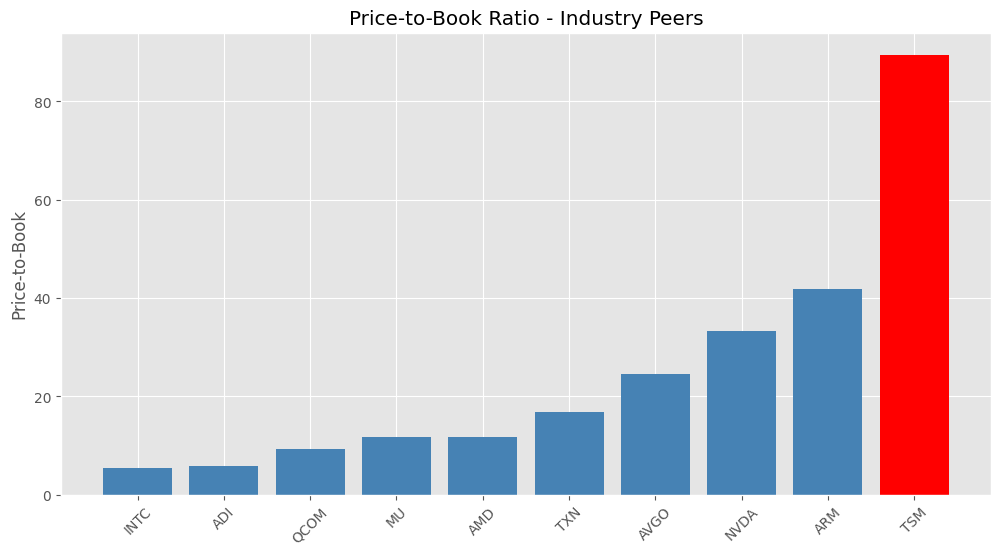

In [93]:
# ============================================================
# Step 4 - Business Question 2
# Is the Company Expensive or Cheap?
# Metric 2: Price-to-Book (P/B)
# Industry Peers Only (Group A)
# ============================================================

pb_A = groupA.dropna(subset=['price_to_book']).copy()

pb_A = pb_A.sort_values('price_to_book')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in pb_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    pb_A['symbol'],
    pb_A['price_to_book'],
    color=colors
)

plt.title('Price-to-Book Ratio - Industry Peers')
plt.ylabel('Price-to-Book')
plt.xticks(rotation=45)

plt.show()

### Business Question 2 - Key Findings

TSM has a P/E ratio of approximately 35, which is not the highest among semiconductor peers. Several companies, including ARM, AMD, and Broadcom, trade at significantly higher earnings multiples.

However, TSM has the highest Price-to-Book ratio in the peer group. This suggests that investors assign a substantial premium to the company, likely reflecting its strong profitability, growth prospects, and dominant position in the semiconductor industry.

Overall, TSM appears expensive on a book-value basis, but its earnings valuation remains reasonable relative to several industry peers.

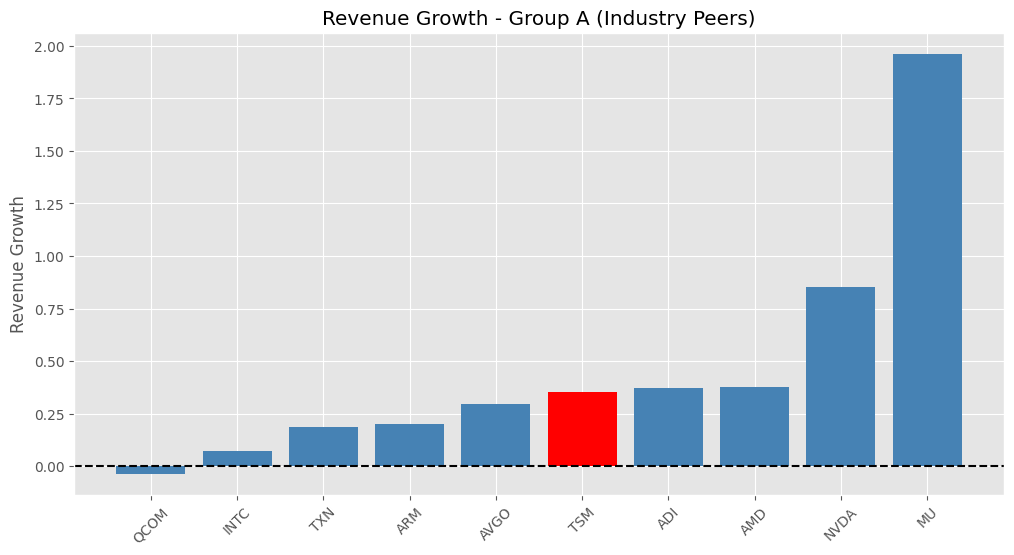

In [94]:
# ============================================================
# Step 5 - Business Question 3
# Is the Company Growing?
# Revenue Growth
# Group A - Industry Peers
# ============================================================

growth_A = groupA.dropna(subset=['revenue_growth']).copy()

growth_A = growth_A.sort_values('revenue_growth')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in growth_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    growth_A['symbol'],
    growth_A['revenue_growth'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Revenue Growth - Group A (Industry Peers)')
plt.ylabel('Revenue Growth')
plt.xticks(rotation=45)

plt.show()

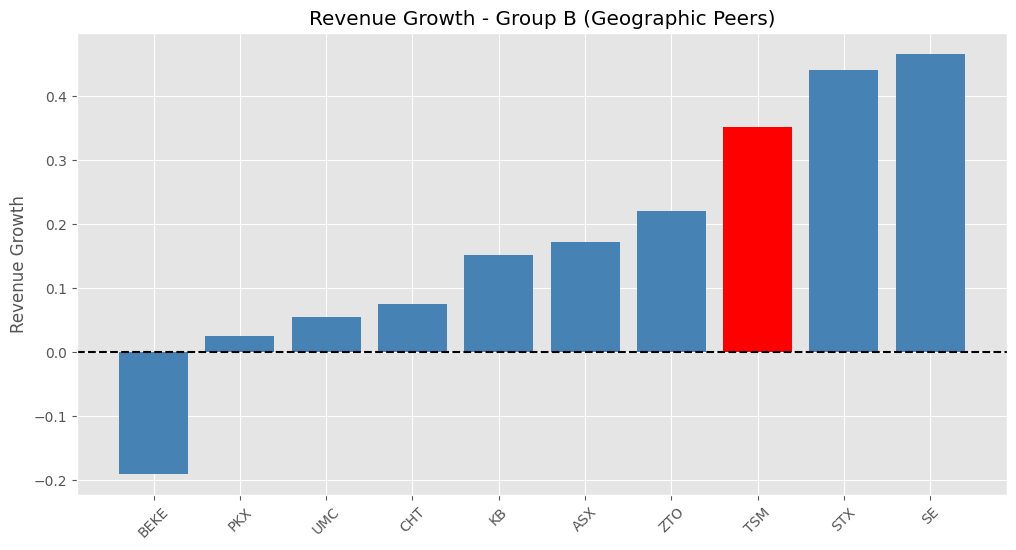

In [95]:
# ============================================================
# Step 5 - Business Question 3
# Is the Company Growing?
# Revenue Growth
# Group B - Geographic Peers
# ============================================================

growth_B = groupB.dropna(subset=['revenue_growth']).copy()

growth_B = growth_B.sort_values('revenue_growth')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in growth_B['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    growth_B['symbol'],
    growth_B['revenue_growth'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Revenue Growth - Group B (Geographic Peers)')
plt.ylabel('Revenue Growth')
plt.xticks(rotation=45)

plt.show()

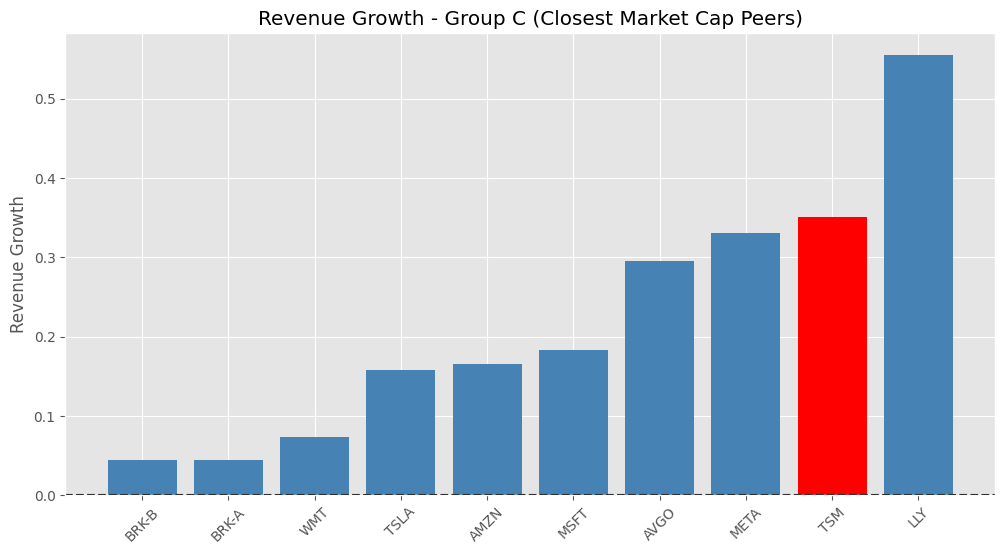

In [96]:
# ============================================================
# Step 5 - Business Question 3
# Is the Company Growing?
# Revenue Growth
# Group C - Closest Market Cap Peers
# ============================================================

growth_C = groupC.dropna(subset=['revenue_growth']).copy()

growth_C = growth_C.sort_values('revenue_growth')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in growth_C['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    growth_C['symbol'],
    growth_C['revenue_growth'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Revenue Growth - Group C (Closest Market Cap Peers)')
plt.ylabel('Revenue Growth')
plt.xticks(rotation=45)

plt.show()

### Business Question 3 - Key Findings

TSM demonstrates strong revenue growth across all peer groups.

Within the semiconductor industry, TSM ranks among the strongest performers, trailing only a few exceptional companies such as Micron and NVIDIA. In the geographic peer group, TSM is one of the fastest-growing companies and clearly exceeds the median growth rate.

Among companies with similar market capitalization, TSM ranks near the top and outperforms several major global corporations, including Microsoft, Amazon, Meta, and Tesla.

Overall, the evidence suggests that TSM is experiencing strong and sustained growth.

In [97]:
print("Debt to Equity:", company['debt_to_equity'])
print("Free Cash Flow:", company['free_cashflow'])

Debt to Equity: 18.447
Free Cash Flow: 719158444032.0


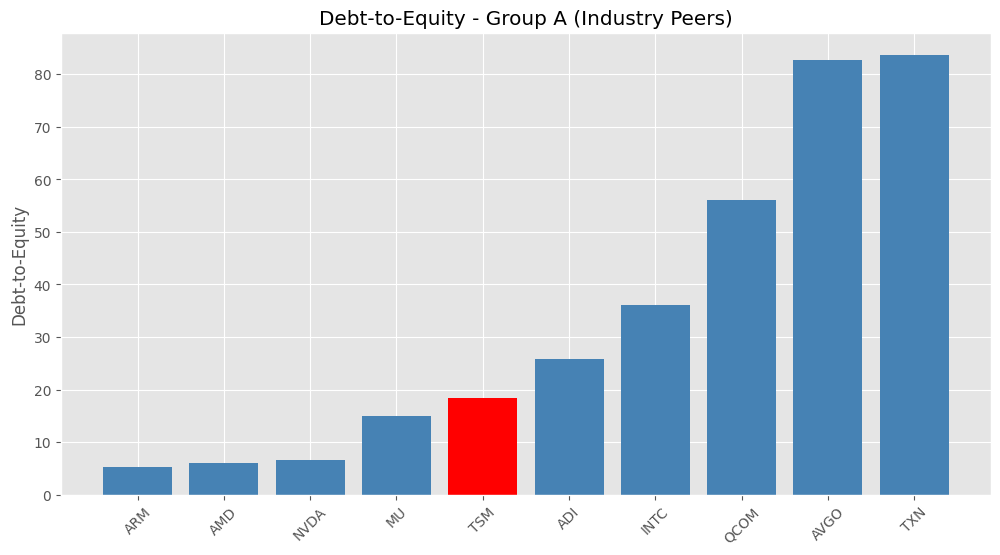

In [98]:
# ============================================================
# Step 6 - Business Question 4
# Is the Company Financially Solid?
# Debt-to-Equity
# Group A - Industry Peers
# ============================================================

de_A = groupA.dropna(subset=['debt_to_equity']).copy()

de_A = de_A.sort_values('debt_to_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in de_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    de_A['symbol'],
    de_A['debt_to_equity'],
    color=colors
)

plt.title('Debt-to-Equity - Group A (Industry Peers)')
plt.ylabel('Debt-to-Equity')
plt.xticks(rotation=45)

plt.show()

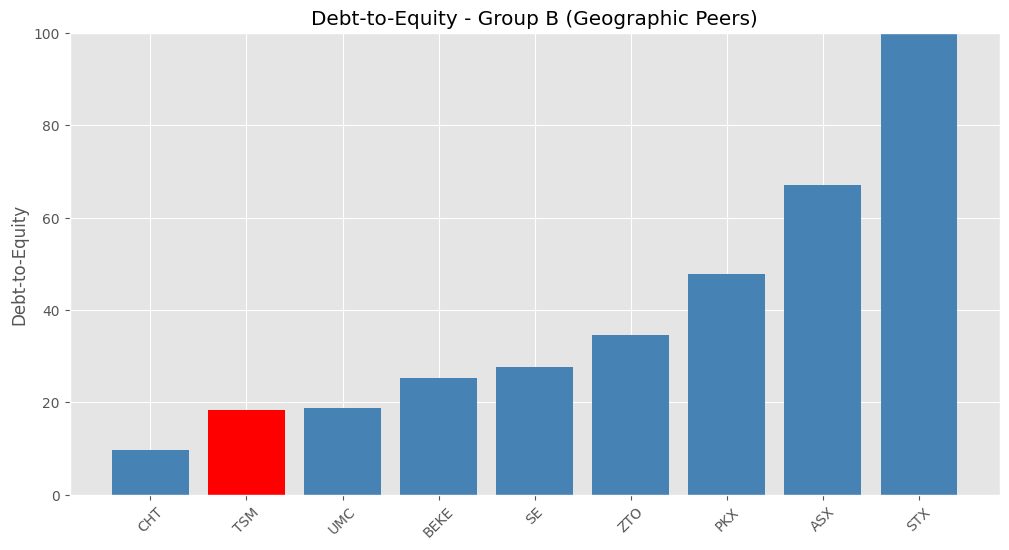

In [99]:
# STX is an extreme debt-to-equity outlier.
# The y-axis is capped to improve readability.

de_B = groupB.dropna(subset=['debt_to_equity']).copy()
de_B = de_B.sort_values('debt_to_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in de_B['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    de_B['symbol'],
    de_B['debt_to_equity'],
    color=colors
)

plt.title('Debt-to-Equity - Group B (Geographic Peers)')
plt.ylabel('Debt-to-Equity')
plt.xticks(rotation=45)

plt.ylim(0, 100)

plt.show()

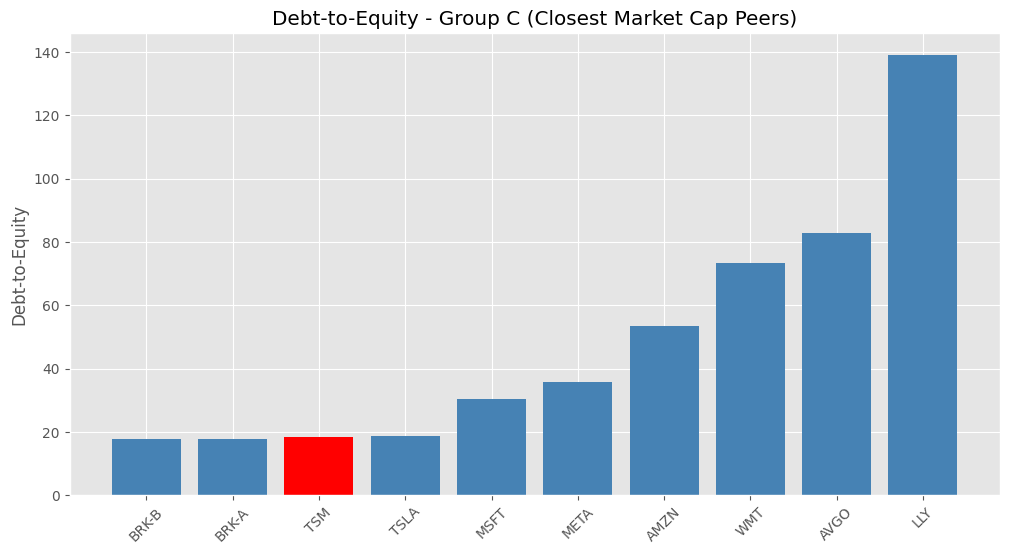

In [100]:
# ============================================================
# Step 6 - Business Question 4
# Debt-to-Equity
# Group C - Closest Market Capitalization
# ============================================================

de_C = groupC.dropna(subset=['debt_to_equity']).copy()

de_C = de_C.sort_values('debt_to_equity')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in de_C['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    de_C['symbol'],
    de_C['debt_to_equity'],
    color=colors
)

plt.title('Debt-to-Equity - Group C (Closest Market Cap Peers)')
plt.ylabel('Debt-to-Equity')
plt.xticks(rotation=45)

plt.show()

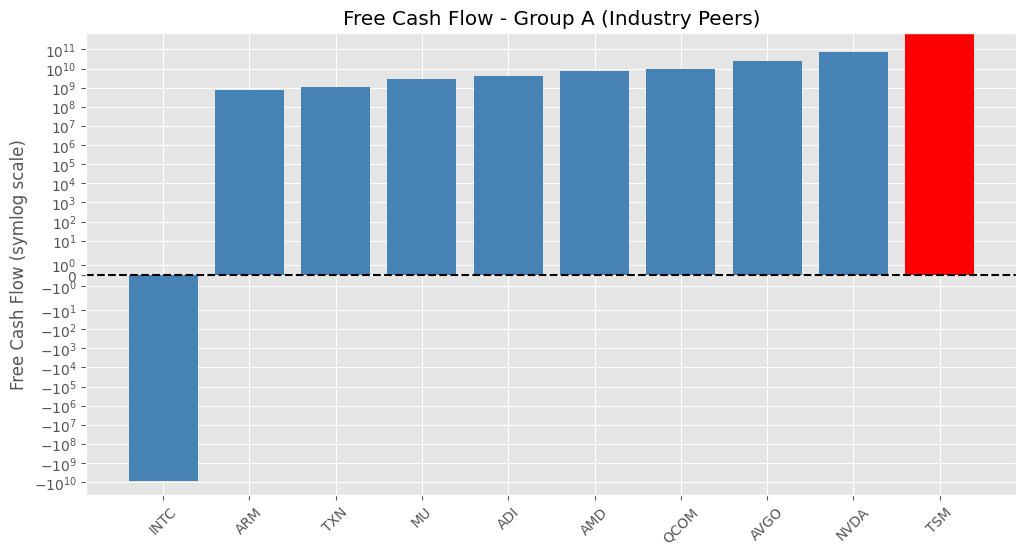

In [101]:
# ============================================================
# Step 6 - Business Question 4
# Free Cash Flow
# Group A - Industry Peers
# Log Scale
# ============================================================

fcf_A = groupA.dropna(subset=['free_cashflow']).copy()

fcf_A = fcf_A.sort_values('free_cashflow')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in fcf_A['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    fcf_A['symbol'],
    fcf_A['free_cashflow'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')


# A symmetric logarithmic scale is used because free cash flow
# values vary substantially across companies and include negative values.
# Log-like scale that also handles negative values
plt.yscale('symlog')

plt.title('Free Cash Flow - Group A (Industry Peers)')
plt.ylabel('Free Cash Flow (symlog scale)')
plt.xticks(rotation=45)

plt.show()

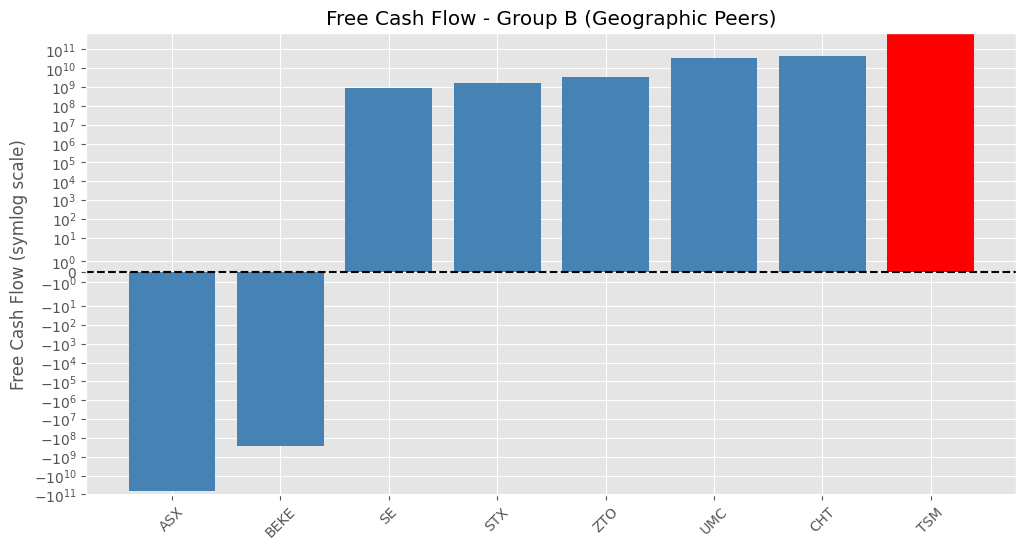

In [102]:
# ============================================================
# Step 6 - Business Question 4
# Free Cash Flow
# Group B - Geographic Peers
# ============================================================

fcf_B = groupB.dropna(subset=['free_cashflow']).copy()

fcf_B = fcf_B.sort_values('free_cashflow')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in fcf_B['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    fcf_B['symbol'],
    fcf_B['free_cashflow'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

# A symmetric logarithmic scale is used because free cash flow
# values vary substantially across companies and include negative values.
plt.yscale('symlog')

plt.title('Free Cash Flow - Group B (Geographic Peers)')
plt.ylabel('Free Cash Flow (symlog scale)')
plt.xticks(rotation=45)

plt.show()

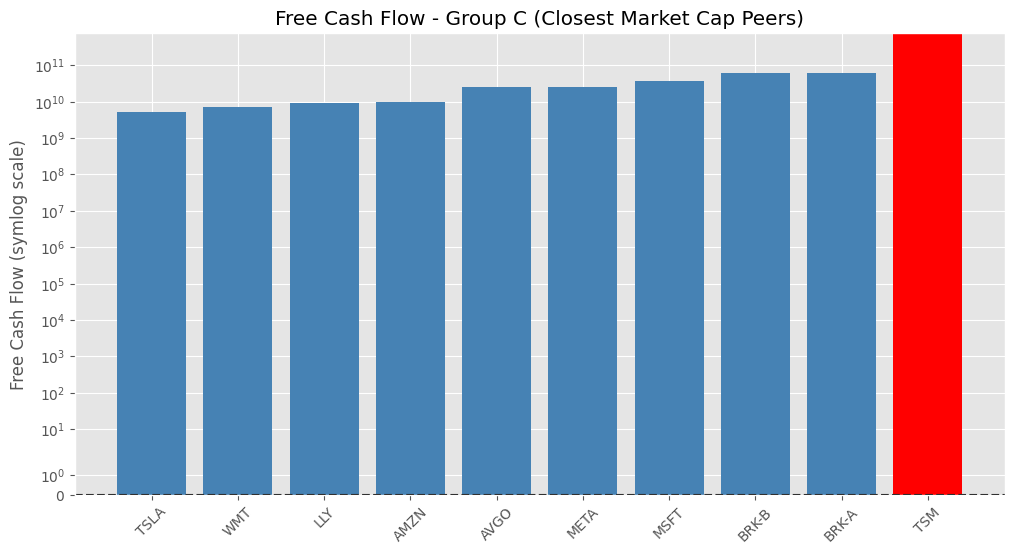

In [103]:
# ============================================================
# Step 6 - Business Question 4
# Free Cash Flow
# Group C - Closest Market Capitalization
# ============================================================

fcf_C = groupC.dropna(subset=['free_cashflow']).copy()

fcf_C = fcf_C.sort_values('free_cashflow')

colors = [
    'red' if symbol == 'TSM' else 'steelblue'
    for symbol in fcf_C['symbol']
]

plt.figure(figsize=(12,6))

plt.bar(
    fcf_C['symbol'],
    fcf_C['free_cashflow'],
    color=colors
)

plt.axhline(0, color='black', linestyle='--')

# A symmetric logarithmic scale is used because free cash flow
# values vary substantially across companies and include negative values.
plt.yscale('symlog')

plt.title('Free Cash Flow - Group C (Closest Market Cap Peers)')
plt.ylabel('Free Cash Flow (symlog scale)')
plt.xticks(rotation=45)

plt.show()

### Business Question 4 - Key Findings

TSM appears financially solid across all peer groups.

Its Debt-to-Equity ratio is relatively low compared with most industry, geographic, and market-cap peers, indicating a conservative use of debt financing.

In addition, TSM generates exceptionally high free cash flow. The company ranks among the strongest cash generators in every comparison group and outperforms most peers by a substantial margin.

Overall, the evidence suggests that TSM has a strong financial position, low leverage, and significant cash-generation capacity.

# Final Summary

The company analyzed in this homework was Taiwan Semiconductor Manufacturing Company (TSM), selected according to the assignment requirements. Homework 1 highlighted the importance of comparing firms using profitability, size, growth, and risk metrics, which motivated a deeper company-level fundamental analysis. Building on that approach, this homework evaluated TSM relative to several peer groups using profitability, valuation, growth, and financial strength indicators.

The profitability analysis showed that TSM is one of the strongest companies across all peer groups. Both profit margins and return on equity were consistently above the median and ranked among the best performers in the semiconductor industry. This indicates that TSM converts revenue into profits efficiently and generates strong returns for shareholders.

From a valuation perspective, TSM appears expensive on a Price-to-Book basis, as it has the highest Price-to-Book ratio among its industry peers. However, its Price-to-Earnings ratio is moderate compared with several semiconductor companies that trade at substantially higher earnings multiples. The company's strong revenue growth supports part of this premium valuation, suggesting that investors are willing to pay more for its future growth prospects.

The growth analysis showed that TSM is expanding at a strong rate despite its already very large size. Revenue growth was consistently above the median in all comparison groups and ranked among the strongest performers in the industry and among companies with similar market capitalization.

The financial strength analysis did not reveal major concerns. TSM maintains a relatively low Debt-to-Equity ratio compared with most peers, indicating a conservative use of debt financing. In addition, the company generates exceptionally high free cash flow, demonstrating strong cash-generation capability and financial flexibility.

Some peer companies had missing values for specific metrics, such as Return on Equity and valuation measures. These observations were excluded from the relevant charts and comparisons. However, sufficient peer data remained available, and the missing values did not materially affect the overall conclusions of the analysis.

Overall, the analysis suggests that TSM is a highly profitable, growing, and financially strong company. Although the stock appears expensive on certain valuation measures, its strong fundamentals and growth profile provide substantial support for that premium valuation.
